# Librerías

In [1]:
import os
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

### 1. Lectura de datos

Leemos los datos

In [2]:
hcc2_ann = sc.read_10x_mtx("data/GSE166635_RAW/GSM5076750_HCC2")

Coste lectura: 11s

In [3]:
# Tamaño 16077 x 33694 (barcode x feature / células x genes)
hcc2_ann

AnnData object with n_obs × n_vars = 9112 × 33694
    var: 'gene_ids', 'feature_types'

In [4]:
print(hcc2_ann.obs)
print(hcc2_ann.var)

Empty DataFrame
Columns: []
Index: [AAACCCAAGATCGCTT-1, AAACCCAAGGGAACAA-1, AAACCCAAGTACAGAT-1, AAACCCACACGAGGAT-1, AAACCCACAGGCGAAT-1, AAACCCACATATCGGT-1, AAACCCAGTTCGAGCC-1, AAACCCAGTTTACTTC-1, AAACCCATCGTTCTAT-1, AAACGAAAGCCTCTCT-1, AAACGAAAGCTGACAG-1, AAACGAAAGGCCGCTT-1, AAACGAAAGGGCGAAG-1, AAACGAACAAATCAAG-1, AAACGAACAACTGGTT-1, AAACGAACATCACGGC-1, AAACGAACATGAAAGT-1, AAACGAAGTCACTGAT-1, AAACGAATCAGGTGTT-1, AAACGAATCTACCACC-1, AAACGAATCTATCGGA-1, AAACGCTAGAAACACT-1, AAACGCTAGAGTGTTA-1, AAACGCTAGATGGTCG-1, AAACGCTAGGAACGCT-1, AAACGCTCAGTTAAAG-1, AAACGCTGTAGATTAG-1, AAACGCTGTCACGTGC-1, AAACGCTGTTCAGCGC-1, AAACGCTTCACCGGTG-1, AAACGCTTCCGACAGC-1, AAACGCTTCTTGCGCT-1, AAAGAACAGATAGCAT-1, AAAGAACAGCCATTGT-1, AAAGAACAGCGGGTTA-1, AAAGAACAGGGCAACT-1, AAAGAACCAAAGGTTA-1, AAAGAACCATCGATAC-1, AAAGAACGTGTCTCCT-1, AAAGAACGTTCCACGG-1, AAAGGATAGAGAATCT-1, AAAGGATCAACTAGAA-1, AAAGGATCAGGTAGTG-1, AAAGGATGTCGGAAAC-1, AAAGGATGTGCCCACA-1, AAAGGGCAGAGCCGTA-1, AAAGGGCCAAATCGGG-1, AAAGGGCCAATTGGTC-1, AAAG

In [5]:
print(hcc2_ann.X)

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 14848681 stored elements and shape (9112, 33694)>
  Coords	Values
  (655, 3)	1.0
  (744, 3)	1.0
  (1005, 3)	1.0
  (1159, 3)	1.0
  (1223, 3)	1.0
  (1361, 3)	1.0
  (1863, 3)	1.0
  (2144, 3)	1.0
  (2542, 3)	1.0
  (2565, 3)	1.0
  (3587, 3)	1.0
  (3903, 3)	1.0
  (4844, 3)	1.0
  (4936, 3)	1.0
  (5174, 3)	1.0
  (5194, 3)	1.0
  (5288, 3)	1.0
  (5396, 3)	1.0
  (5397, 3)	1.0
  (5452, 3)	1.0
  (5507, 3)	1.0
  (5971, 3)	1.0
  (6201, 3)	1.0
  (6394, 3)	1.0
  (6701, 3)	1.0
  :	:
  (3489, 33691)	1.0
  (3600, 33691)	1.0
  (3902, 33691)	1.0
  (5031, 33691)	1.0
  (5090, 33691)	1.0
  (5327, 33691)	1.0
  (5363, 33691)	1.0
  (5497, 33691)	1.0
  (5500, 33691)	1.0
  (5716, 33691)	1.0
  (5798, 33691)	1.0
  (6266, 33691)	1.0
  (6456, 33691)	1.0
  (7181, 33691)	1.0
  (7327, 33691)	1.0
  (7390, 33691)	1.0
  (7396, 33691)	1.0
  (7533, 33691)	1.0
  (7535, 33691)	1.0
  (7743, 33691)	1.0
  (8236, 33691)	1.0
  (8586, 33691)	1.0
  (8629, 33691)	1.0
  (90

### 2. Limpieza de datos

Pasamos a limpiar las muestras que no tienen sentido, lo que queremos obtener al final:

    - células con número de genes entre 200 y 7000 (a comprobar)
    - células con proporción de mitocondria menor de 20% (a comprobar)

In [6]:
# Añadimos columna a var paragenes mitocondriales, MT- para referir a genes mitocondriales de humanos
hcc2_ann.var["mt"] = hcc2_ann.var_names.str.startswith("MT-")

# Calculamos métricas de control de calidad, añadimos la variable que nos interesa "mt"
sc.pp.calculate_qc_metrics(hcc2_ann, qc_vars=["mt"], inplace=True)
# Se modifica directamente la matriz, añadiendo columnas de métricas

In [7]:
hcc2_ann.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCCAAGATCGCTT-1,839,6.733402,2247.0,7.717796,45.393858,57.009346,68.669337,84.913218,178.0,5.187386,7.921673
AAACCCAAGGGAACAA-1,844,6.739337,2101.0,7.650645,44.312232,55.306997,66.968110,83.626844,104.0,4.653960,4.950024
AAACCCAAGTACAGAT-1,411,6.021023,5848.0,8.674026,93.604651,94.681943,96.391929,100.000000,5325.0,8.580356,91.056770
AAACCCACACGAGGAT-1,471,6.156979,3396.0,8.130648,86.631331,89.075383,92.020024,100.000000,2701.0,7.901748,79.534744
AAACCCACAGGCGAAT-1,979,6.887553,3166.0,8.060540,62.318383,68.193304,74.763108,84.870499,1305.0,7.174724,41.219204
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCACTCGATA-1,170,5.141664,4532.0,8.419139,97.352162,98.455428,100.000000,100.000000,4344.0,8.376781,95.851723
TTTGTTGCAGCTTTCC-1,179,5.192957,4989.0,8.515191,97.414311,98.416516,100.000000,100.000000,4797.0,8.475954,96.151527
TTTGTTGGTTAGAAGT-1,1060,6.966967,2930.0,7.983099,42.286689,55.529010,66.757679,80.887372,169.0,5.135798,5.767918
TTTGTTGTCGCCTAGG-1,677,6.519147,1832.0,7.513709,48.144105,60.807860,72.980349,90.338428,138.0,4.934474,7.532751


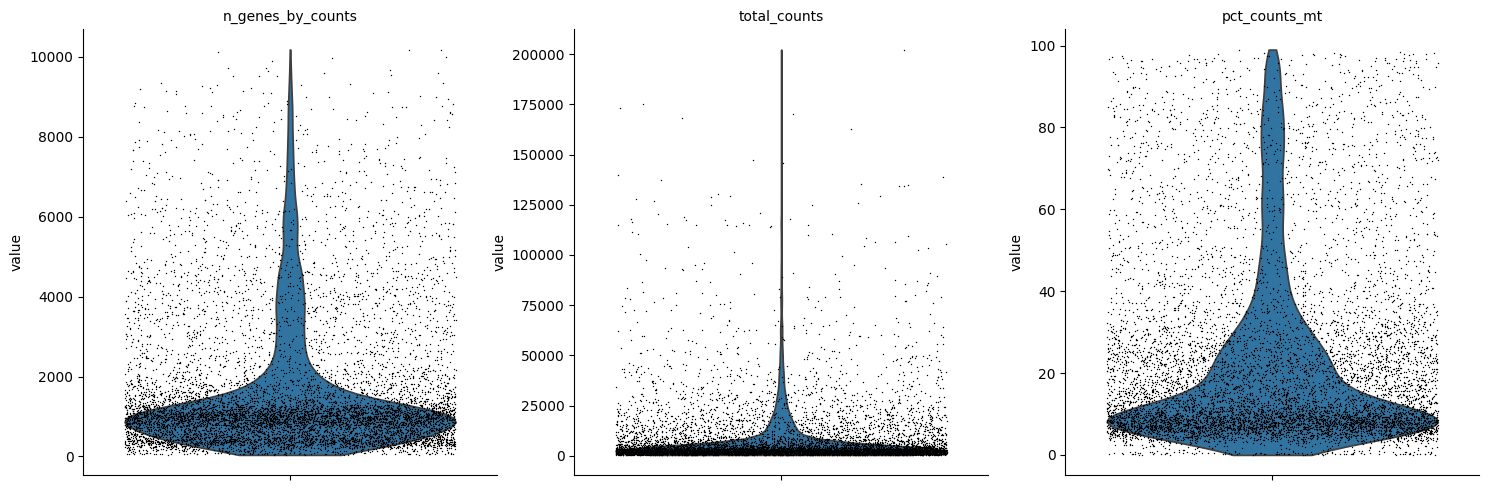

In [9]:
sc.pl.violin(
    hcc2_ann,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

Las gráficas de violín son distintas a los otros datos, mirar mejor los umbrales

<Axes: xlabel='pct_counts_mt', ylabel='Count'>

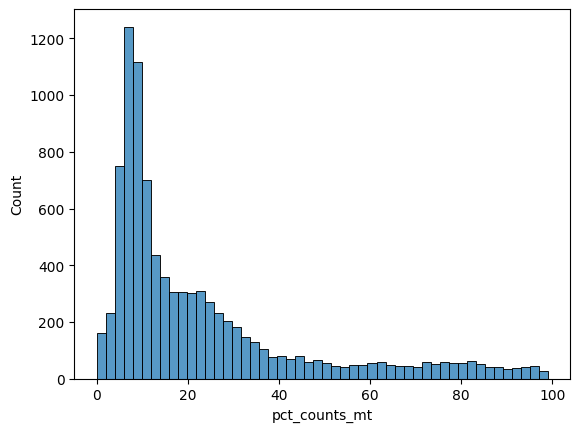

In [10]:
sns.histplot(hcc2_ann.obs["pct_counts_mt"])

#### 2.1. Filtrado por número de genes

Miramos principalmente el "**n_genes_by_counts**", que es la métrica que cuenta el número de genes que tiene mínimo un *count* (existe) en la célula. Es decir, número de genes que tiene una célula

In [ ]:
hcc2_filter_gen_counts = hcc2_ann[(hcc2_ann.obs["n_genes_by_counts"] >= 200) & (hcc2_ann.obs["n_genes_by_counts"] <= 7000)]

# También se podría hacer:
#a = hcc2_ann.copy()
#sc.pp.filter_cells(a, min_genes=200)
#sc.pp.filter_cells(a, max_genes=7000)

# 8635 muestras resultantes
print(hcc2_filter_gen_counts.obs["n_genes_by_counts"])
#print(a.obs["n_genes_by_counts"])

AAACCCAAGATCGCTT-1     839
AAACCCAAGGGAACAA-1     844
AAACCCAAGTACAGAT-1     411
AAACCCACACGAGGAT-1     471
AAACCCACAGGCGAAT-1     979
                      ... 
TTTGTTGCAATACGCT-1     487
TTTGTTGCACATACGT-1     890
TTTGTTGGTTAGAAGT-1    1060
TTTGTTGTCGCCTAGG-1     677
TTTGTTGTCGTAGGAG-1    1734
Name: n_genes_by_counts, Length: 8635, dtype: int64


In [ ]:
# Miramos los datos que han sido filtrados
hcc2_gen_counts_left = hcc2_ann[(hcc2_ann.obs["n_genes_by_counts"] < 200) | (hcc2_ann.obs["n_genes_by_counts"] > 7000)]

hcc2_lower_bound_gen_counts = hcc2_ann[hcc2_ann.obs["n_genes_by_counts"] < 200]

hcc2_upper_bound_gen_counts = hcc2_ann[hcc2_ann.obs["n_genes_by_counts"] > 7000]

# Crear fichero csv con los datos para analizar
#hcc2_gen_counts_left.obs.to_csv("hcc2_gen_counts_left_obs.csv")
#hcc2_lower_bound_gen_counts.obs.to_csv("hcc2_lower_bound_gen_counts.csv")
#hcc2_upper_bound_gen_counts.obs.to_csv("hcc2_upper_bound_gen_counts.csv")

In [ ]:
hcc1_upper_bound_A = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] > 7000) & (hcc1_ann.obs["n_genes_by_counts"] < 7201)]
hcc1_upper_bound_B = hcc1_ann[(hcc1_ann.obs["n_genes_by_counts"] > 7200) & (hcc1_ann.obs["n_genes_by_counts"] < 7501)]

hcc1_upper_bound_A.obs.to_csv("hcc1_upper_bound_A.csv")
hcc1_upper_bound_B.obs.to_csv("hcc1_upper_bound_B.csv")

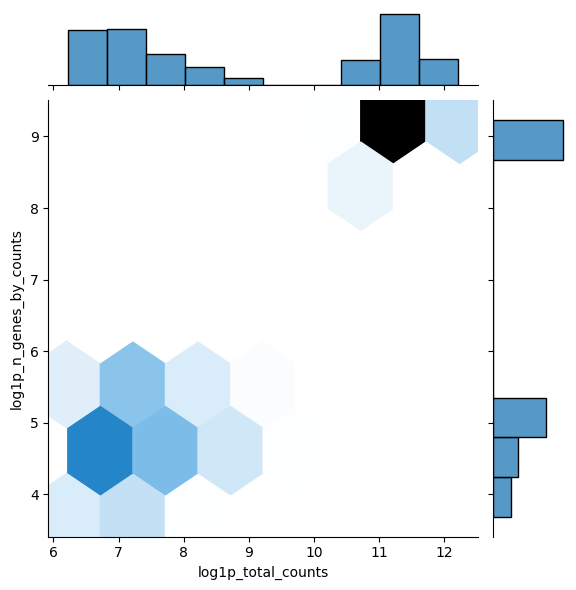

In [13]:
sns.jointplot(
    data=hcc2_gen_counts_left.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

<Axes: xlabel='pct_counts_mt', ylabel='Count'>

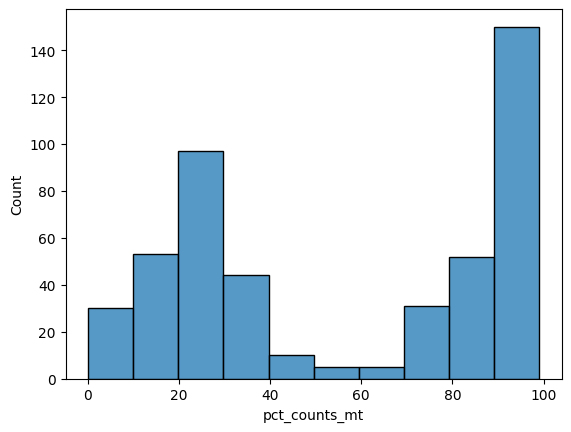

In [14]:
sns.histplot(hcc2_gen_counts_left.obs["pct_counts_mt"])

#### 2.2. Filtrado por mitocondria

In [ ]:
hcc2_filtered = hcc2_filter_gen_counts[(hcc2_filter_gen_counts.obs["pct_counts_mt"] <= 20)]

# 5543 muestras resultantes
hcc2_filtered.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCCAAGATCGCTT-1,839,6.733402,2247.0,7.717796,45.393858,57.009346,68.669337,84.913218,178.0,5.187386,7.921673
AAACCCAAGGGAACAA-1,844,6.739337,2101.0,7.650645,44.312232,55.306997,66.968110,83.626844,104.0,4.653960,4.950024
AAACCCAGTTCGAGCC-1,895,6.797940,2178.0,7.686621,42.470156,54.269972,65.426997,81.864096,331.0,5.805135,15.197429
AAACGAAAGCCTCTCT-1,821,6.711740,2263.0,7.724888,43.128590,56.915599,69.376933,85.815289,171.0,5.147494,7.556341
AAACGAAAGCTGACAG-1,783,6.664409,1728.0,7.455298,42.013889,53.645833,65.972222,83.622685,184.0,5.220356,10.648149
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCAATACGCT-1,487,6.190315,824.0,6.715384,40.898058,53.033981,65.169903,100.000000,52.0,3.970292,6.310680
TTTGTTGCACATACGT-1,890,6.792344,1929.0,7.565275,42.405391,51.944012,63.037843,79.782271,130.0,4.875197,6.739243
TTTGTTGGTTAGAAGT-1,1060,6.966967,2930.0,7.983099,42.286689,55.529010,66.757679,80.887372,169.0,5.135798,5.767918
TTTGTTGTCGCCTAGG-1,677,6.519147,1832.0,7.513709,48.144105,60.807860,72.980349,90.338428,138.0,4.934474,7.532751


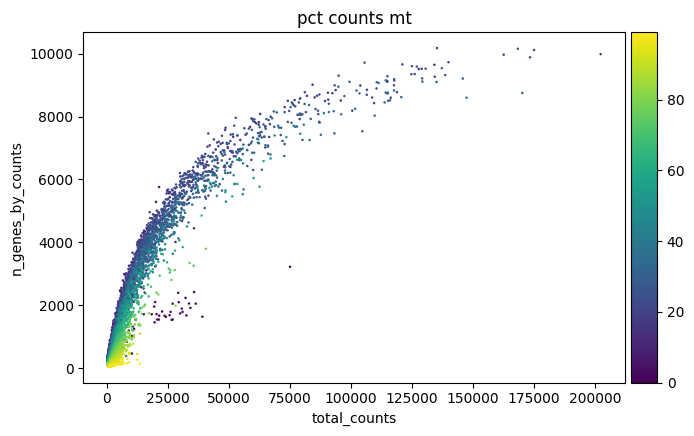

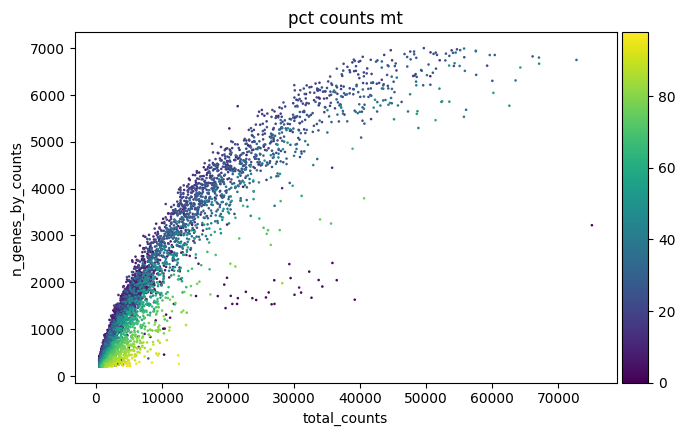

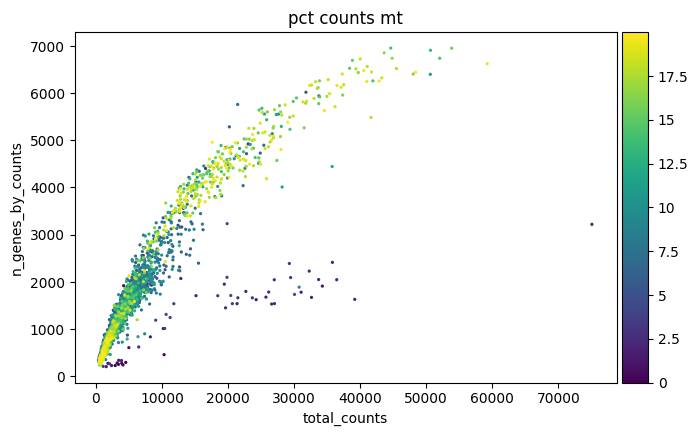

In [16]:
sc.pl.scatter(hcc2_ann, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

sc.pl.scatter(hcc2_filter_gen_counts, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

sc.pl.scatter(hcc2_filtered, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

# TODO:
- Doublet
- Normalización
- Clasificar exhausted y non_exhausted
- FBA